🏆 Top 10 Most Voted Restaurants:
          Restaurant Name  Votes  Aggregate rating
                     Toit  10934               4.8
                 Truffles   9667               4.7
         Hauz Khas Social   7931               4.3
                Peter Cat   7574               4.3
AB's - Absolute Barbecues   6907               4.6
          Barbeque Nation   5966               4.9
              Big Brewsky   5705               4.5
AB's - Absolute Barbecues   5434               4.9
          The Black Pearl   5385               4.1
                    BarBQ   5288               4.2

⚠️ Bottom 10 Least Voted Restaurants:
                  Restaurant Name  Votes  Aggregate rating
              Khalsa Eating Point      0               0.0
        Radha Swami Chaat Bhandar      0               0.0
       Ram Ram Ji Kachori Bhandar      0               0.0
               Rana's Food Corner      0               0.0
              Sanjay Chicken Shop      0               0.0
             

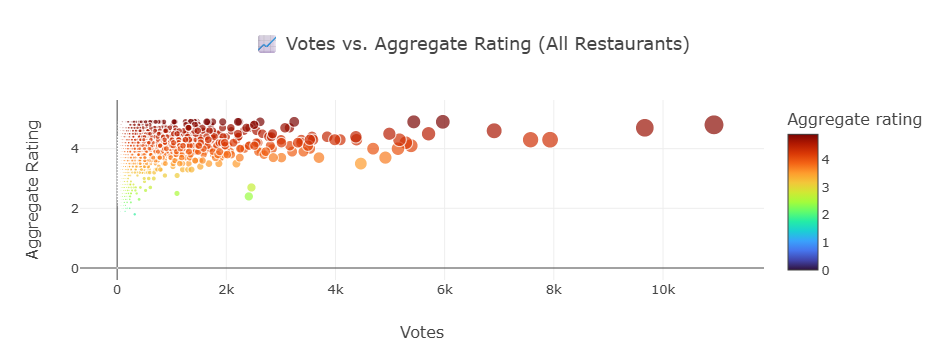


📊 Pearson Correlation between Votes and Aggregate Rating: 0.314


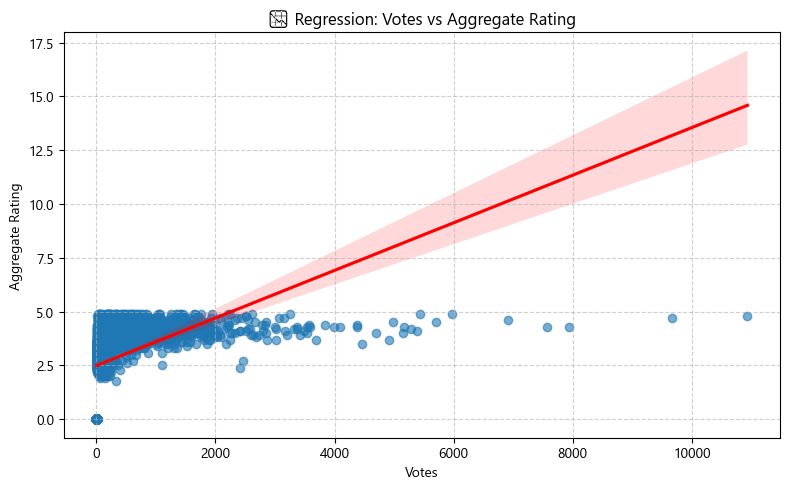

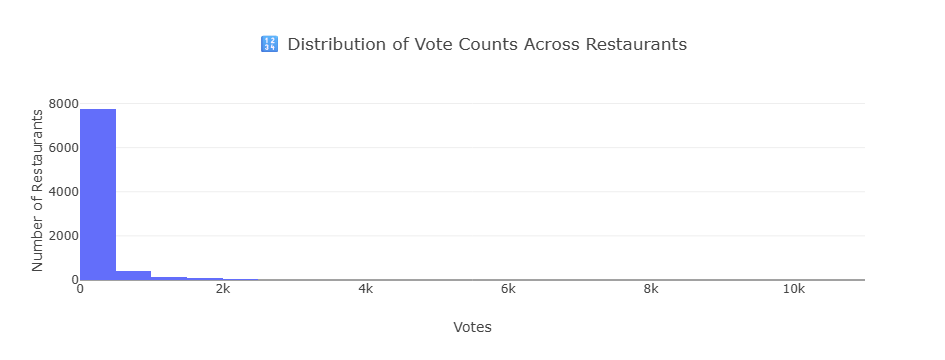

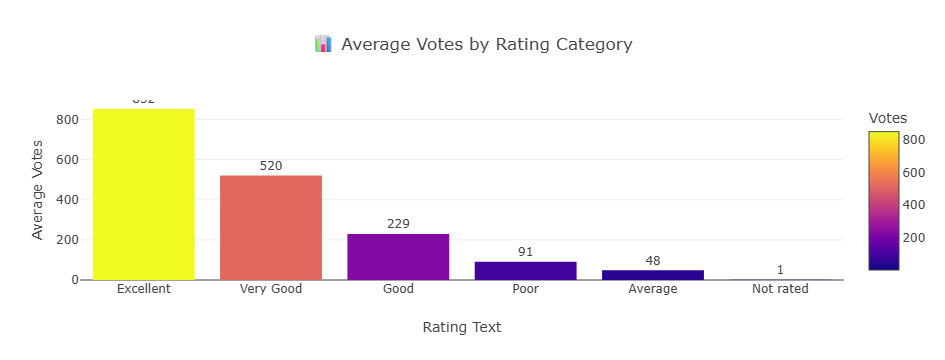

In [11]:
# 📦 Import Libraries
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 📥 Load Dataset
df = pd.read_csv(r"C:\Users\acer\Downloads\Data Analysis Internship__Dataset__Cognifyz Technologies.csv")

# 🔧 Pre-cleaning
df = df.dropna(subset=['Votes', 'Aggregate rating', 'Restaurant Name', 'Rating text'])
df = df[df['Votes'] >= 0]  # Remove any weird negative vote values
df['Votes'] = df['Votes'].astype(int)

# --------------------------------------------------------------------------------
# 🔍 STEP 1: Top 10 Highest & Lowest Voted Restaurants
# --------------------------------------------------------------------------------
top_votes = df[['Restaurant Name', 'Votes', 'Aggregate rating']].sort_values(by='Votes', ascending=False).head(10)
low_votes = df[['Restaurant Name', 'Votes', 'Aggregate rating']].sort_values(by='Votes', ascending=True).head(10)

print("🏆 Top 10 Most Voted Restaurants:")
print(top_votes.to_string(index=False))

print("\n⚠️ Bottom 10 Least Voted Restaurants:")
print(low_votes.to_string(index=False))

# --------------------------------------------------------------------------------
# 📊 STEP 2: Scatter Plot – Votes vs Aggregate Rating
# --------------------------------------------------------------------------------
fig1 = px.scatter(
    df[df['Votes'] > 0],  # Exclude 0-vote entries
    x='Votes',
    y='Aggregate rating',
    color='Aggregate rating',
    size='Votes',
    hover_name='Restaurant Name',
    title='📈 Votes vs. Aggregate Rating (All Restaurants)',
    color_continuous_scale='Turbo'
)
fig1.update_layout(
    xaxis_title='Votes',
    yaxis_title='Aggregate Rating',
    plot_bgcolor='white',
    font=dict(size=13)
)
fig1.show()

# --------------------------------------------------------------------------------
# 🧮 STEP 3: Pearson Correlation between Votes and Rating
# --------------------------------------------------------------------------------
correlation = df[['Votes', 'Aggregate rating']].corr().iloc[0, 1].round(3)
print(f"\n📊 Pearson Correlation between Votes and Aggregate Rating: {correlation}")

# Visualize with regression line (Seaborn)
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Votes', y='Aggregate rating', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("📉 Regression: Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------
# 🔢 STEP 4: Histogram of Vote Distribution
# --------------------------------------------------------------------------------
fig2 = px.histogram(
    df[df['Votes'] > 0],
    x='Votes',
    nbins=50,
    title='🔢 Distribution of Vote Counts Across Restaurants',
    color_discrete_sequence=['#636EFA']
)
fig2.update_layout(xaxis_title='Votes', yaxis_title='Number of Restaurants')
fig2.show()

# --------------------------------------------------------------------------------
# 🧠 STEP 5: Average Votes by Rating Category
# --------------------------------------------------------------------------------
votes_by_rating = df.groupby('Rating text')['Votes'].mean().reset_index().sort_values(by='Votes', ascending=False)

fig3 = px.bar(
    votes_by_rating,
    x='Rating text',
    y='Votes',
    color='Votes',
    text='Votes',
    title='📊 Average Votes by Rating Category',
    color_continuous_scale='Plasma'
)
fig3.update_traces(texttemplate='%{text:.0f}', textposition='outside')
fig3.update_layout(
    xaxis_title='Rating Text',
    yaxis_title='Average Votes',
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)
fig3.show()
